# Quantum Chemistry

NicDeclic  
2026-09-25

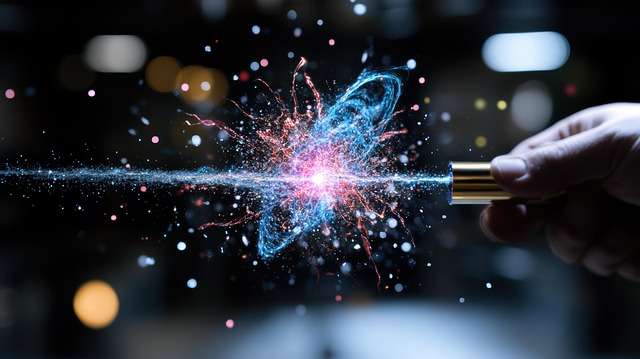

> *“An atom has no identity of its own. Only a function within the
> whole.”*  
> — **Professor Alvin**

------------------------------------------------------------------------

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nicdeclic/quantum-molecular-computing/blob/main/posts/quantum-chemistry/index.ipynb)

In [1]:
import sys
if 'google.colab' in sys.modules:
    # 1. Download qmc.py from GitHub
    !wget -q https://raw.githubusercontent.com/nicdeclic/quantum-molecular-computing/main/qmc.py
    
    # 2. Download requirements.txt from GitHub
    !wget -q https://raw.githubusercontent.com/nicdeclic/quantum-molecular-computing/main/requirements.txt

    # 3. Install dependencies
    !pip install -q -r requirements.txt

sys.path.insert(0, "../..") # Select root directory
from qmc import * # QMC library

%reload_ext autoreload
%autoreload 2

------------------------------------------------------------------------

## Computing Molecules

Could it be that the capacity to process and manipulate information is
woven into the very fabric of molecules?

We now turn to explore the untapped potential of atoms and their
chemical bonds to create sophisticated computational systems.

------------------------------------------------------------------------

## Chemical Bonds

The molecules of primary interest here are those with carbon atoms,
owing to their fundamental ability to form four covalent bonds. While
other elements, such as silicon, share this tetravalent property, carbon
will serve as our foundational element throughout this blog due to its
central role in organic chemistry.

Carbon atoms do not dance alone in this molecular choreography; they
interact with other key elements, notably hydrogen (which typically
forms one bond), oxygen (which forms two), and nitrogen (which forms
three). Combined with carbon, these elements constitute the elemental
building blocks of a rich and complex chemistry:

In [2]:
with schemdraw.Drawing() as d:
    d.config(fontsize=14)

    # --- Row 1: Single Bond (H - C) ---
    d += elm.Line(lw=2).at((0, 0)).to((2.5, 0))
    # Draw dots AFTER the line so they sit cleanly on top
    d += elm.Dot(radius=0.45).at((0, 0)).color('#1E88E5').fill('#E3F2FD').label('H', loc='center', color='black')
    d += elm.Dot(radius=0.45).at((2.5, 0)).color('#424242').fill('#E0E0E0').label('C', loc='center', color='black')
    d += elm.Label().at((3.6, 0)).label('Hydrogen – Carbon: 1 bond', halign='left', valign='center')

    # --- Row 2: Double Bond (O = C) ---
    d += elm.Line(lw=4.5).at((0, -2)).to((2.5, -2))
    d += elm.Dot(radius=0.45).at((0, -2)).color('#E53935').fill('#FFCDD2').label('O', loc='center', color='black')
    d += elm.Dot(radius=0.45).at((2.5, -2)).color('#424242').fill('#E0E0E0').label('C', loc='center', color='black')
    d += elm.Label().at((3.6, -2)).label('Oxygen – Carbon: 2 bonds', halign='left', valign='center')

    # --- Row 3: Triple Bond (N ≡ C) ---
    d += elm.Line(lw=7.5).at((0, -4)).to((2.5, -4))
    d += elm.Dot(radius=0.45).at((0, -4)).color('#43A047').fill('#C8E6C9').label('N', loc='center', color='black')
    d += elm.Dot(radius=0.45).at((2.5, -4)).color('#424242').fill('#E0E0E0').label('C', loc='center', color='black')
    d += elm.Label().at((3.6, -4)).label('Nitrogen – Carbon: 3 bonds', halign='left', valign='center')

Chemical bonds can naturally be harnessed to encode discrete binary
states. For instance, a single bond between two carbon atoms can be
defined as representing a state **“0”**, whereas a double bond can
represent a state **“1”**. We will not be using triple bonds here.

------------------------------------------------------------------------

## Orbitals

Where do these specific bond valencies and spatial bond angles actually
originate? The answer lies within the concept of atomic and molecular
orbitals.

An orbital is a region of space around an atomic nucleus where the
probability of finding an electron is highest. These regions are
governed by mathematical wavefunctions—the direct solutions to the
fundamental equations of quantum mechanics.

These orbitals exhibit varied geometries and scales, classified by sets
of quantum numbers. The $s$, $p$, $d$, and $f$ subshells, for instance,
possess distinct spatial shapes that directly dictate how atoms bond.
The $p$-orbitals, with their characteristic dumbbell-shaped lobes
oriented along Cartesian axes, are critically important for the
formation of the covalent bonds prevalent in organic and aromatic
architectures.

When atomic orbitals interact, they combine to produce **hybrid
orbitals**, which ultimately govern the geometry of molecular
structures. For carbon:  
\* **$sp^3$ hybridization** yields four single bonds symmetrically
arranged in a three-dimensional tetrahedron (with $\approx 109.5^\circ$
angles).  
\* **$sp^2$ hybridization** yields planar geometries
($\approx 120^\circ$ angles), creating the structural framework for
double bonds.  
\* **$sp$ hybridization** yields linear geometries ($180^\circ$ angles),
establishing triple bonds.

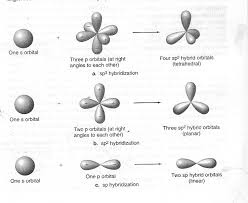

### Delocalization in Conjugated Systems

In conjugated and aromatic systems, electrons are free to delocalize
across multiple atomic centers:

Take benzene as the quintessential example: the $\pi$ (pi) electrons
that form the alternating double bonds are not strictly bound between
adjacent pairs of carbon atoms. Instead, they form a continuous,
delocalized electron cloud extending uniformly over the entire hexagonal
ring.

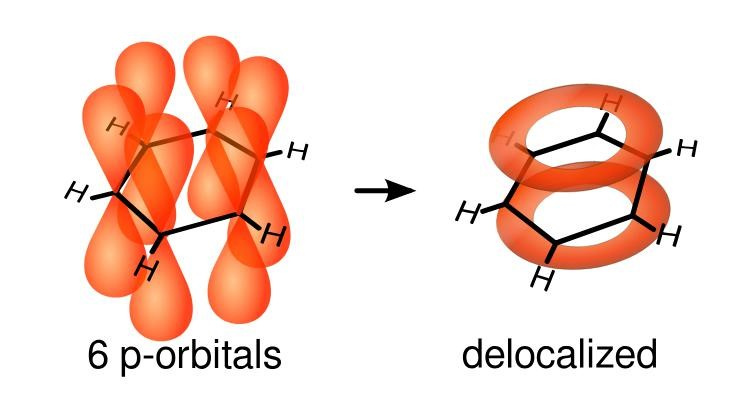

This resonance phenomenon is a direct physical manifestation of quantum
mechanics. It demonstrates how quantum entities occupy coherent
superpositions rather than classical point-like positions. To be clear:
these are not localized particles mechanically “spinning in circles”
around the ring, but rather an integrated, collective electronic state.

This delocalization is far from a mere theoretical curiosity; it carries
profound practical implications. The continuous nature of the
$\pi$-cloud dictates the molecule’s chemical stability, its electronic
band structure, its charge transport capabilities, and its optical
response.

------------------------------------------------------------------------

## The Initial Spark: Trivalent Carbon Nodes

The computational potential of a carbon atom bonded to three adjacent
atoms ($sp^2$ planar center) is particularly intriguing. Such an atom
acts naturally as a **branching node** within a molecular graph, where
each chemical bond functions as a logical interconnect.

To satisfy carbon’s fundamental tetravalence (four total bonds),
**exactly one** of these three bonds can be a double bond at any given
moment, while the remaining two must be single bonds. Consequently, the
local bond configuration at this trivalent node can manifest in three
mutually exclusive states:

1.  Bond $a$ is double; bonds $b$ and $c$ are single.
2.  Bond $b$ is double; bonds $a$ and $c$ are single.
3.  Bond $c$ is double; bonds $a$ and $b$ are single.

This set of degenerate configurations corresponds directly to the
resonance structures of the molecular node.

We can express this physical valence constraint through the following
Boolean relation:

$$ (A \mathbin{\text{Xor}} B \mathbin{\text{Xor}} C) \mathbin{\text{Xor}} (A \mathbin{\text{And}} B \mathbin{\text{And}} C) = \text{"1"} $$

Or represented as an equivalent logic circuit:

In [3]:
with schemdraw.Drawing() as d:
    d.config(fontsize=12, unit=2.5)

    # 1. Gates: 3-input XOR (top) and 3-input AND (bottom)
    # inputs=3 exposes anchors: in1, in2, in3
    xor3 = d.add(logic.Xor(inputs=3).right().at((4, 2)))
    and3 = d.add(logic.And(inputs=3).right().at((4, 0)))

    # 2. Final 2-input XOR combining both branches
    xor_final = d.add(logic.Xor().right().at((6, 1)))
    d.add(elm.Wire('|-').at(xor3.out).to(xor_final.in1))
    d.add(elm.Wire('|-').at(and3.out).to(xor_final.in2))

    # Output line constrained to "1"
    d.add(elm.Line().right(1.5).at(xor_final.out).label('"1"', loc='right'))

    # 3. Clean input bus routing for A, B, C
    # Input A (top pin: in1)
    d.add(elm.Line().left(3).at(xor3.in1).label('A', loc='left'))
    d.add(elm.Dot().at((xor3.in1[0]-0.5,xor3.in1[1])))
    d.add(elm.Wire('|-').at((xor3.in1[0]-0.5,xor3.in1[1])).to(and3.in1))

    # Input B (middle pin: in2)
    d.add(elm.Line().left(3).at(xor3.in2).label('B', loc='left'))
    d.add(elm.Dot().at((xor3.in2[0]-1.0,xor3.in2[1])))
    d.add(elm.Wire('|-').at((xor3.in2[0]-1.0,xor3.in2[1])).to(and3.in2))

    # Input C (bottom pin: in3)
    d.add(elm.Line().left(3).at(xor3.in3).label('C', loc='left'))
    d.add(elm.Dot().at((xor3.in3[0]-1.5,xor3.in3[1])))
    d.add(elm.Wire('|-').at((xor3.in3[0]-1.5,xor3.in3[1])).to(and3.in3))


Given that combining an **AND** operation with an **XOR** operation
provides the functional completeness required to synthesize a universal
**NAND** gate, we immediately see that all the necessary mathematical
ingredients for universal computation are naturally embedded within the
valence rules of a single carbon node.

There is clearly substantial theoretical potential here — the challenge
is simply learning how to tame and harness it…

It was precisely this early, encouraging realization that provided the
initial momentum to dive deeper into the exploration of molecular
quantum circuits.

------------------------------------------------------------------------

## Protobits

------------------------------------------------------------------------